In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [20]:
# pip install kagglehub[pandas-datasets]

# Data Loading from Kaggle

In [21]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load the KenPom/Barttorvik dataset as a pandas DataFrame.
# Only the listed columns are imported in order to focus on key performance metrics and seeding information.
kenpom = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS, 
    "nishaanamin/march-madness-data", 
    "KenPom Barttorvik.csv",
    pandas_kwargs={
        "usecols": ["YEAR", "TEAM", "KADJ EM", "BARTHAG", "SEED", "ROUND", "QUAD ID"]
    }
)

# Load the Heat Check Tournament Index dataset as a pandas DataFrame.
# This includes power and seeding/ranking.
heat = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "nishaanamin/march-madness-data",
    "Heat Check Tournament Index.csv",
    pandas_kwargs={
        "usecols": ["YEAR", "TEAM", "POWER", "PATH", "POOL S-RANK", "NCAA S-RANK"]
    }
)

# Load the Shooting Splits dataset as a pandas DataFrame.
# These columns focus on 3-point shooting, close 2-point shooting, and dunk efficiency.
shoot = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS, 
    "nishaanamin/march-madness-data", 
    "Shooting Splits.csv",
    pandas_kwargs={
        "usecols": [
            "YEAR", "TEAM", "THREES FG%", "THREES FG%D", "THREES SHARE",
            "CLOSE TWOS FG%", "CLOSE TWOS FG%D", "DUNKS FG%"
        ]
    }
)

# Display the first 5 rows of each dataset to confirm correct loading and to provide an overview of the data structure and key columns.
print("\nKenPom Barttorvik\n", kenpom.head())
print("\nHeat Check Ratings\n", heat.head())
print("\nShooting Splits\n", shoot.head())


KenPom Barttorvik
    YEAR  QUAD ID      TEAM  SEED  ROUND  KADJ EM  BARTHAG
0  2026        1     Akron    12      0  12.7986    0.773
1  2026        1   Alabama     4      0  25.7196    0.934
2  2026        2   Arizona     1      0  37.6556    0.978
3  2026        2  Arkansas     4      0  26.0527    0.934
4  2026        2       BYU     6      0  23.2459    0.887

Heat Check Ratings
    YEAR      TEAM  POWER  PATH  POOL S-RANK  NCAA S-RANK
0  2026     Akron   63.2  83.4           47           48
1  2026   Alabama   84.4  72.4           13           14
2  2026   Arizona   94.0  66.1            2            2
3  2026  Arkansas   82.5  67.8           10           16
4  2026       BYU   78.3  72.9           23           24

Shooting Splits
    YEAR      TEAM  DUNKS FG%  CLOSE TWOS FG%  CLOSE TWOS FG%D  THREES FG%  \
0  2026     Akron       93.1            65.0             55.6        38.5   
1  2026   Alabama       85.9            61.4             56.2        35.8   
2  2026   Arizona   

# Data Preprocessing
## Merging Multiple Datasets

In [22]:
df = kenpom.merge(heat, on=["YEAR", "TEAM"], how="inner").merge(shoot, on=["YEAR", "TEAM"], how="inner")
df.head()

,YEAR,QUAD ID,TEAM,SEED,ROUND,KADJ EM,BARTHAG,POWER,PATH,POOL S-RANK,NCAA S-RANK,DUNKS FG%,CLOSE TWOS FG%,CLOSE TWOS FG%D,THREES FG%,THREES SHARE,THREES FG%D
0,2026,1,Akron,12,0,12.7986,0.773,63.2,83.4,47,48,93.1,65.0,55.6,38.5,45.1,35.1
1,2026,1,Alabama,4,0,25.7196,0.934,84.4,72.4,13,14,85.9,61.4,56.2,35.8,53.7,33.5
2,2026,2,Arizona,1,0,37.6556,0.978,94.0,66.1,2,2,93.4,64.1,52.5,36.0,26.8,31.4
3,2026,2,Arkansas,4,0,26.0527,0.934,82.5,67.8,10,16,92.0,67.1,61.9,38.9,33.4,31.7
4,2026,2,BYU,6,0,23.2459,0.887,78.3,72.9,23,24,84.2,66.9,62.1,34.9,39.8,35.3


## Encoding and Scaling

In [23]:
# Split the full dataset into two subsets: 1. past tournament results, where ROUND is known and not 0 and 2. 2026 teams, where ROUND == 0 and outcomes are not yet known
df_past = df[df["ROUND"] != 0].copy()
df_2026 = df[df["ROUND"] == 0].copy()

# Map tournament round values to ordered numeric values for modeling.
rounds = {64: 1, 32: 2, 16: 3, 8: 4, 4: 5, 2: 6, 1: 7}

# Create a new column ROUND_ENCODED in the past tournament results set to hold the numeric encoding of the ROUND values.
df_past["ROUND_ENCODED"] = df_past["ROUND"].map(rounds)

# Store count of rows before dropping for reporting
# Convert to int for modeling and drop rows with unmapped round values
before = len(df_past)
df_past = df_past.dropna(subset=["ROUND_ENCODED"]).copy()
df_past["ROUND_ENCODED"] = df_past["ROUND_ENCODED"].astype(int)

# Print rows dropped and class distribution of the target variables after encoding to confirm the encoding worked.
print(f"Dropped {before - len(df_past)} rows with unmapped ROUND values")
print("Class distribution:\n", df_past["ROUND_ENCODED"].value_counts().sort_index())

Dropped 0 rows with unmapped ROUND values
Class distribution:
 ROUND_ENCODED
1    384
2    192
3     96
4     48
5     24
6     12
7     12
Name: count, dtype: int64


In [24]:
# Create the feature matrix by removing columns that should not be used as predictors
X = df_past.drop(columns=["ROUND", "ROUND_ENCODED", "TEAM", "QUAD ID", "YEAR"])

# Create the target vector using the encoded round values
y = df_past["ROUND_ENCODED"]

# Display the structure of the feature matrix to confirm it contains expected columns and data types for modeling
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 64 to 831
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SEED             768 non-null    int64  
 1   KADJ EM          768 non-null    float64
 2   BARTHAG          768 non-null    float64
 3   POWER            768 non-null    float64
 4   PATH             768 non-null    float64
 5   POOL S-RANK      768 non-null    int64  
 6   NCAA S-RANK      768 non-null    int64  
 7   DUNKS FG%        768 non-null    float64
 8   CLOSE TWOS FG%   768 non-null    float64
 9   CLOSE TWOS FG%D  768 non-null    float64
 10  THREES FG%       768 non-null    float64
 11  THREES SHARE     768 non-null    float64
 12  THREES FG%D      768 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 84.0 KB


In [25]:
#import necessary modules for modeling, preprocessing, and evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split the dataset into training and testing sets with stratification to maintain class distribution, and set a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
ct = ColumnTransformer([("scaling", StandardScaler(), ["KADJ EM", "BARTHAG", "DUNKS FG%", 
                                                       "CLOSE TWOS FG%", "CLOSE TWOS FG%D", "THREES FG%", 
                                                       "THREES SHARE", "THREES FG%D", "POWER", "PATH"])], 
                                                       remainder="passthrough")

# Model Instantiation and Exploring Different Models

In [26]:
# Define a dictionary of models to evaluate
# Each model is defined as a pipeline that includes the preprocessing steps followed by the classifier
# Hyperparameters for each model are set based on best practices for multi-class classification and to address class imbalance
models = {"Logistic Regression": Pipeline([("preprocessor", ct), ("classifier", LogisticRegression(max_iter=1000, C=1.0, multi_class="multinomial", solver="lbfgs", class_weight="balanced", random_state=42))]),
    "Random Forest": Pipeline([("preprocessor", ct), ("classifier", RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=5, class_weight="balanced", random_state=42, n_jobs=-1))]),
    "Gradient Boosting": Pipeline([("preprocessor", ct), ("classifier", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42))])
}

In [27]:
# Define labels for the tournament round to use in the classification report for better interpretability of results
ROUND_LABELS = ["R64", "R32", "S16", "E8", "F4", "Final", "Champ"]
results = {}

# Loop through each model in the model dictionary to fit, predict, evaluate, and store the results for comparison
for name, model in models.items():
    # fit the models to the training data, predict on the test set, calculate accuracy, and perform 5-fold cross-validation to evaluate generalization performance
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(model, X, y, cv=5, scoring="accuracy")

    # Store the model, predictions, test accuracy, and cross-validation results in the results dictionary for later comparison and analysis
    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "test_acc": acc,
        "cv_mean": cv.mean(),
        "cv_std": cv.std(),
    }

    # Print the test accuracy, cross-validation results, and classification report for each model in order to evaluate performance and identify which model performs best
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  CV Accuracy   : {cv.mean():.4f} ± {cv.std():.4f}")
    print(f"{'='*50}")
    present_labels = sorted(y_test.unique())
    present_names = [ROUND_LABELS[i - 1] for i in present_labels]
    print(classification_report(y_test, y_pred, labels=present_labels,
                                target_names=present_names, zero_division=0))


  Logistic Regression
  Test Accuracy : 0.3636
  CV Accuracy   : 0.4167 ± 0.0325
              precision    recall  f1-score   support

         R64       0.79      0.62      0.70        77
         R32       0.22      0.13      0.16        39
         S16       0.00      0.00      0.00        19
          E8       0.00      0.00      0.00        10
          F4       0.08      0.40      0.13         5
       Final       0.07      0.50      0.12         2
       Champ       0.00      0.00      0.00         2

    accuracy                           0.36       154
   macro avg       0.16      0.24      0.16       154
weighted avg       0.45      0.36      0.39       154


  Random Forest
  Test Accuracy : 0.4675
  CV Accuracy   : 0.5105 ± 0.0397
              precision    recall  f1-score   support

         R64       0.78      0.61      0.69        77
         R32       0.37      0.46      0.41        39
         S16       0.18      0.21      0.20        19
          E8       0.21     

# Hyperparameter Tuning

In [28]:
from sklearn.model_selection import GridSearchCV

# Instantiating pipeline for hyperparameter tuning for Gradient Boosting Model
pipe = Pipeline(steps=[('preprocessor', ct),
                      ('classifier', GradientBoostingClassifier(random_state=42))])

# Parameter grid to explore different hyperparameter values
param_grid = [{'classifier': [GradientBoostingClassifier(random_state=42)],
               'classifier__max_depth': [3, 4, 5],
               'classifier__max_features': ['sqrt', 'log2'],
               'classifier__n_estimators': [100, 250, 500],
               'classifier__min_samples_leaf': [5, 10, 20],
               'classifier__learning_rate': [0.05, 0.1, 0.2]
              }]

# Instantiating and fitting grid search with training data
grid = GridSearchCV(pipe, param_grid, cv=5, return_train_score=True)
grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'classifier': [GradientBoost...ndom_state=42)], 'classifier__learning_rate': [0.05, 0.1, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__max_features': ['sqrt', 'log2'], ...}]"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('scaling', ...)]"


In [29]:
# Printing and visualizing grid search results
print("Best Parameters: {}".format(grid.best_params_))
print("Best Cross-Validation Train Score: {:.2f}".format(
    grid.cv_results_['mean_train_score'][grid.best_index_]))
print("Best Cross-Validation Test Score: {:.2f}".format(grid.best_score_))
print("Test Set Accuracy: {:.2f}".format(grid.score(X_test, y_test)))

Best Parameters: {'classifier': GradientBoostingClassifier(random_state=42), 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 250}
Best Cross-Validation Train Score: 1.00
Best Cross-Validation Test Score: 0.56
Test Set Accuracy: 0.49


# Test Results Visualization

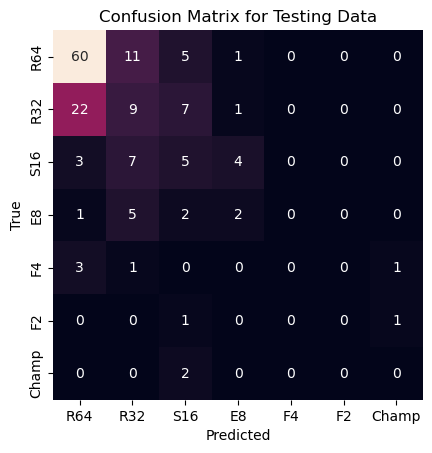

In [30]:
# Using the best model from the grid search
best_model = grid.best_estimator_

# Generate test predictions
y_test_pred = best_model.predict(X_test)

# Create confusion matrix to visualize test results
train_mat = confusion_matrix(y_test, y_test_pred)
sns.heatmap(train_mat, xticklabels=["R64", "R32", "S16", "E8", "F4", "F2", "Champ"], 
            yticklabels=["R64", "R32", "S16", "E8", "F4", "F2", "Champ"], 
            square=True, annot=True, cbar=False, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Testing Data")

plt.show()


# Exploring 2026 Predictions

In [32]:
# Observe 2026 dataset
df_2026.info()
X_2026 = df_2026

<class 'pandas.core.frame.DataFrame'>
Index: 64 entries, 0 to 63
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YEAR             64 non-null     int64  
 1   QUAD ID          64 non-null     int64  
 2   TEAM             64 non-null     object 
 3   SEED             64 non-null     int64  
 4   ROUND            64 non-null     int64  
 5   KADJ EM          64 non-null     float64
 6   BARTHAG          64 non-null     float64
 7   POWER            64 non-null     float64
 8   PATH             64 non-null     float64
 9   POOL S-RANK      64 non-null     int64  
 10  NCAA S-RANK      64 non-null     int64  
 11  DUNKS FG%        64 non-null     float64
 12  CLOSE TWOS FG%   64 non-null     float64
 13  CLOSE TWOS FG%D  64 non-null     float64
 14  THREES FG%       64 non-null     float64
 15  THREES SHARE     64 non-null     float64
 16  THREES FG%D      64 non-null     float64
dtypes: float64(10), int64(6

In [33]:
# Generating 2026 predictions
y_pred_2026 = best_model.predict(X_2026)
df_2026["prediction"] = y_pred_2026

In [34]:
# Observing the prediction distribution across tournament rounds (half of the teams should be eliminated each round)
print(df_2026["prediction"].value_counts())

# Observing which team was predicted to win in 2026 (Michigan was the actual winner)
df_2026[df_2026["prediction"] == 7]

prediction
1    43
3     8
2     7
4     3
7     2
6     1
Name: count, dtype: int64


,YEAR,QUAD ID,TEAM,SEED,ROUND,KADJ EM,BARTHAG,POWER,PATH,POOL S-RANK,NCAA S-RANK,DUNKS FG%,CLOSE TWOS FG%,CLOSE TWOS FG%D,THREES FG%,THREES SHARE,THREES FG%D,prediction
8,2026,4,Duke,1,0,38.8998,0.981,95.0,68.5,1,1,91.5,64.8,54.6,35.1,44.4,30.4,7
19,2026,3,Illinois,3,0,32.1008,0.968,89.2,68.3,6,10,85.9,68.0,60.0,34.7,50.7,31.4,7


In [35]:
# Observing which round was predicted for Michigan
df_2026[df_2026["TEAM"] == "Michigan"]

,YEAR,QUAD ID,TEAM,SEED,ROUND,KADJ EM,BARTHAG,POWER,PATH,POOL S-RANK,NCAA S-RANK,DUNKS FG%,CLOSE TWOS FG%,CLOSE TWOS FG%D,THREES FG%,THREES SHARE,THREES FG%D,prediction
30,2026,1,Michigan,1,0,37.592,0.98,93.9,69.6,3,3,91.1,68.1,54.4,36.0,41.8,30.2,6
